This includes all code relevant to the results in the report. Additional code was produced but has not been included here.

# Task 1.1

In [ ]:
def get_ramp_hit_times(xs):
    hit_times = []

    for trial in range(xs.shape[0]):
        hits = np.where(xs[trial] >= 1)[0]

        if len(hits) > 0:
            hit_times.append(hits[0])
        else:
            hit_times.append(np.nan)

    return np.array(hit_times)


def plot_ramp_hit_histogram(xs, bins=30):
    hit_times = get_ramp_hit_times(xs)
    hit_times = hit_times[~np.isnan(hit_times)]

    plt.xlim(0, xs.shape[1])

    plt.hist(hit_times, bins=bins, color="gray", edgecolor="black")
    plt.xlabel("time when $x_t$ first hits 1")
    plt.ylabel("count")
    plt.title("Histogram of ramp-model bound-hit times")
    plt.show()

In [352]:
#Spike Raster plotter

import numpy as np
import matplotlib.pyplot as plt

def step_plot_raster(spikes, jumps=None, max_trials=30):
    n_trials = min(spikes.shape[0], max_trials)

    plt.figure(figsize=(8, 3.5))

    for trial in range(n_trials):
        spike_times = np.where(spikes[trial] > 0)[0]
        plt.scatter(
            spike_times,
            np.full_like(spike_times, trial),
            s=8,
            color="black"
        )

    #Option to plot jump time
    if jumps is not None:
        plt.scatter(
            jumps[:n_trials],
            np.arange(n_trials),
            s=35,
            color="red",
            marker="x",
            label="jump time"
        )
        plt.legend()

    plt.xlim(0, spikes.shape[1])
    plt.xlabel("time bin")
    plt.ylabel("trial")
    plt.title("Step model spike raster")
    plt.show()


def ramp_plot_raster(spikes, xs=None, max_trials=30):
    n_trials = min(spikes.shape[0], max_trials)

    plt.figure(figsize=(8, 3.5))

    for trial in range(n_trials):
        spike_times = np.where(spikes[trial] > 0)[0]
        plt.scatter(
            spike_times,
            np.full_like(spike_times, trial),
            s=8,
            color="black"
        )

    # Option to plot ramp boundary-hit time
    if xs is not None:
        hit_times = get_ramp_hit_times(xs)

        plt.scatter(
            hit_times[:n_trials],
            np.arange(n_trials),
            s=35,
            color="red",
            marker="x",
            label="bound-hit time"
        )
        plt.legend()

    plt.xlim(0, spikes.shape[1])
    plt.xlabel("time bin")
    plt.ylabel("trial")
    plt.title("Ramp model spike raster")
    plt.show()

In [353]:
def plot_jump_histogram(spikes, jumps, bins=30):
    T = spikes.shape[1]

    plt.hist(
        jumps,
        bins=bins,
        range=(0, T),
        color="gray",
        edgecolor="black"
    )

    plt.xlim(0, T)
    plt.xlabel("jump time")
    plt.ylabel("count")
    plt.title("Histogram of step-model jump times")
    plt.show()

In [354]:
def plot_jump_time_histograms(jump_time_sets, labels, bins=30, T=1000, title="Jump-time distributions"):
    plt.figure(figsize=(7, 3.5))

    colours = ["blue", "green", "red", "orange", "purple"]

    for i in range(len(jump_time_sets)):
        plt.hist(
            jump_time_sets[i],
            bins=bins,
            range=(0, T),
            alpha=0.45,
            label=labels[i],
            color=colours[i],
            edgecolor="black",
            linewidth=0.6,
            density=False
        )

    plt.xlabel("jump time (ms)")
    plt.ylabel("count")
    plt.title(title)
    plt.xlim(0, T)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [355]:
#Plotting ramp trajectories
def plot_ramp_trajectories(xs, max_trials=10):
    n_trials = min(xs.shape[0], max_trials)

    for trial in range(n_trials):
        plt.plot(xs[trial], alpha=0.8)

    plt.axhline(1, color="red", linestyle="--", label="upper bound")
    plt.xlim(0, xs.shape[1])
    plt.ylim(0, 1.05)
    plt.xlabel("time bin")
    plt.ylabel("$x_t$")
    plt.title("Ramp model latent trajectories")
    plt.legend()
    plt.show()

In [356]:
#Plotting rate trajectories
def plot_rate_trajectories(rates, name="Model", max_trials=10):
    n_trials = min(rates.shape[0], max_trials)

    for trial in range(n_trials):
        plt.plot(rates[trial], alpha=0.8)

    plt.xlim(0, rates.shape[1])
    plt.xlabel("time bin")
    plt.ylabel("$r_t$ / firing rate (Hz)")
    plt.title(f"{name} firing-rate trajectories")
    plt.show()

In [ ]:
def plot_ramp_trajectories_with_hit_hist(xs, bins=35, max_trials=5, title=None):
    """
    Compact report plot for ramp-model behaviour.
    Shows a few example latent trajectories and overlays the bound-hit-time
    histogram computed across all simulated trials.
    """
    T = xs.shape[1]
    n_trials = min(xs.shape[0], max_trials)

    hit_times = get_ramp_hit_times(xs)
    hit_times = hit_times[~np.isnan(hit_times)]

    fig, ax_x = plt.subplots(figsize=(8, 3.5))

    ax_hist = ax_x.twinx()
    ax_hist.hist(
        hit_times,
        bins=bins,
        range=(0, T),
        color="0.75",
        edgecolor="none",
        alpha=0.55
    )
    ax_hist.set_ylabel("hit count", color="0.35")
    ax_hist.tick_params(axis="y", colors="0.35", labelsize=8)
    ax_hist.spines["right"].set_color("0.6")
    ax_hist.spines["top"].set_visible(False)

    for trial in range(n_trials):
        ax_x.plot(xs[trial], linewidth=1.3, alpha=0.9)

    ax_x.axhline(1, color="red", linestyle="--", linewidth=1.2)
    ax_x.set_xlim(0, T)
    ax_x.set_ylim(0, 1.08)
    ax_x.set_xlabel("time bin")
    ax_x.set_ylabel("$x_t$")
    ax_x.tick_params(labelsize=8)
    ax_x.spines["top"].set_visible(False)

    if title is not None:
        ax_x.set_title(title, fontsize=10)

    fig.tight_layout(pad=0.5)

    return fig, ax_x, ax_hist




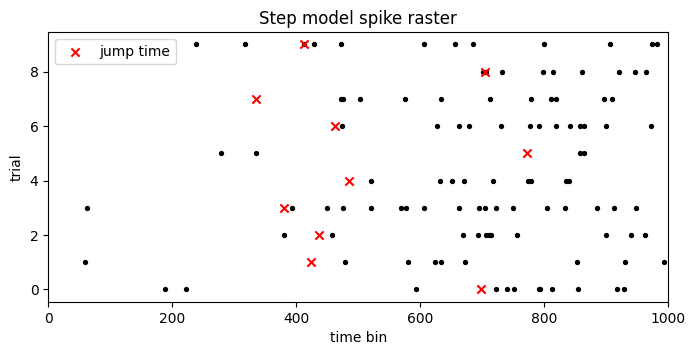

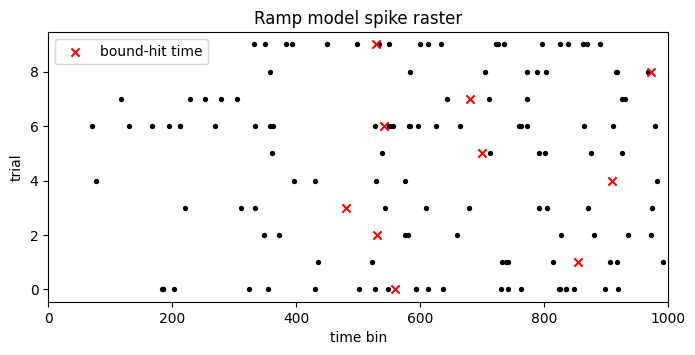

In [358]:
step = StepModel(m=500, r=10, x0=0.1, Rh=20)
spikes, jumps, rates = step.simulate(Ntrials=10, T=1000)
step_plot_raster(spikes, jumps)



ramp = RampModel(beta=1.5, sigma=0.3, x0=0.1, Rh=20)
spikes, xs, rates = ramp.simulate(Ntrials=10, T=1000)
ramp_plot_raster(spikes, xs)


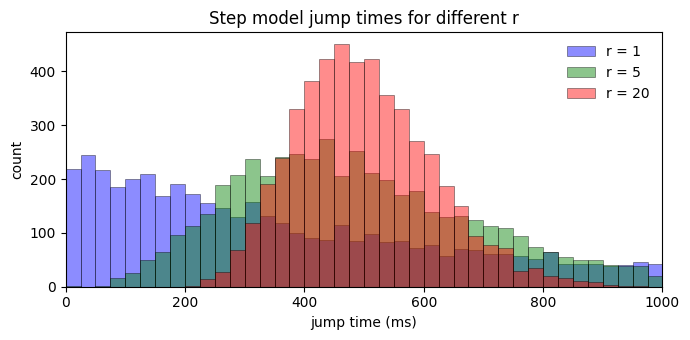

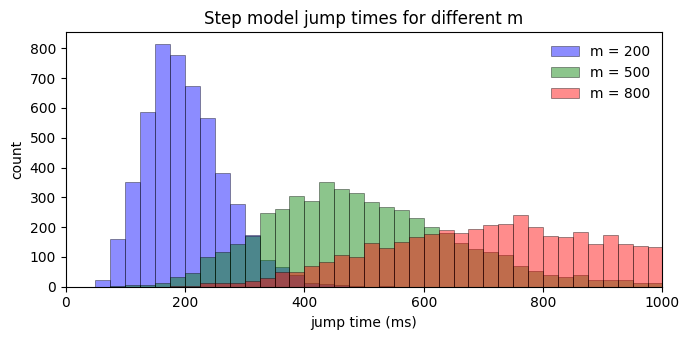

In [ ]:
jump_sets = []
labels = []

for r in [1, 5, 20]:
    step = StepModel(m=500, r=r, x0=0.05, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=5000, T=1000)

    jump_sets.append(jumps)
    labels.append(f"r = {r}")

plot_jump_time_histograms(
    jump_sets,
    labels,
    bins=40,
    T=1000,
    title="Step model jump times for different r"
)


jump_sets = []
labels = []

for m in [200, 500, 800]:
    step = StepModel(m, r=10, x0=0.05, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=5000, T=1000)

    jump_sets.append(jumps)
    labels.append(f"m = {m}")

plot_jump_time_histograms(
    jump_sets,
    labels,
    bins=40,
    T=1000,
    title="Step model jump times for different m"
)




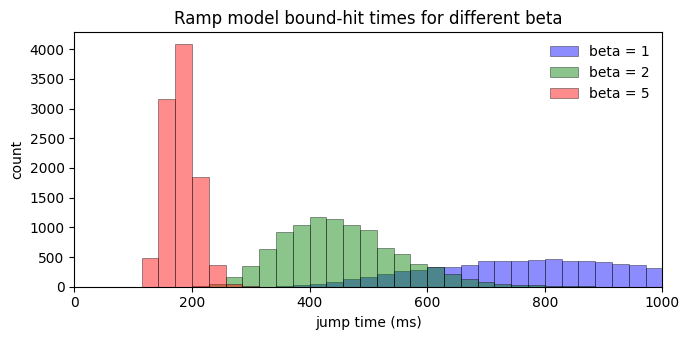

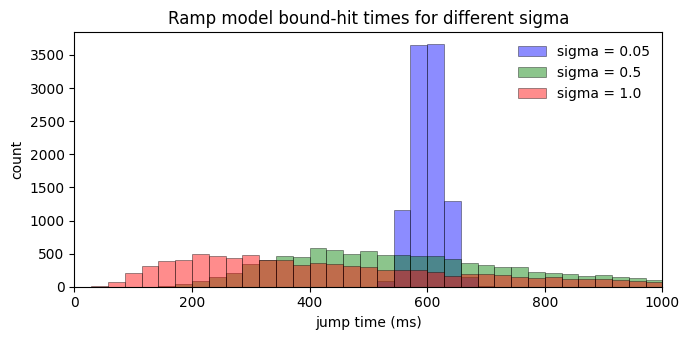

In [360]:
hit_time_sets = []
labels = []

for beta in [1, 2, 5]:
    ramp = RampModel(beta=beta, sigma=0.3, x0=0.1, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=10000, T=1000)

    hit_times = get_ramp_hit_times(xs)
    hit_times = hit_times[~np.isnan(hit_times)]

    hit_time_sets.append(hit_times)
    labels.append(f"beta = {beta}")

plot_jump_time_histograms(
    hit_time_sets,
    labels,
    bins=35,
    T=1000,
    title="Ramp model bound-hit times for different beta"
)


hit_time_sets = []
labels = []

for sigma in [0.05, 0.5, 1.0]:
    ramp = RampModel(beta=1.5, sigma=sigma, x0=0.1, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=10000, T=1000)

    hit_times = get_ramp_hit_times(xs)
    hit_times = hit_times[~np.isnan(hit_times)]

    hit_time_sets.append(hit_times)
    labels.append(f"sigma = {sigma}")

plot_jump_time_histograms(
    hit_time_sets,
    labels,
    bins=35,
    T=1000,
    title="Ramp model bound-hit times for different sigma"
)

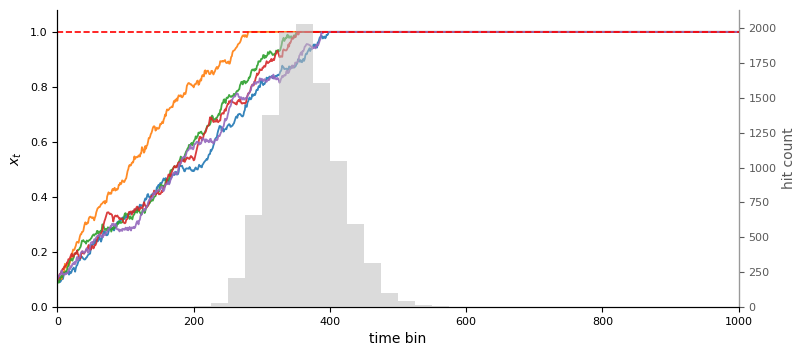

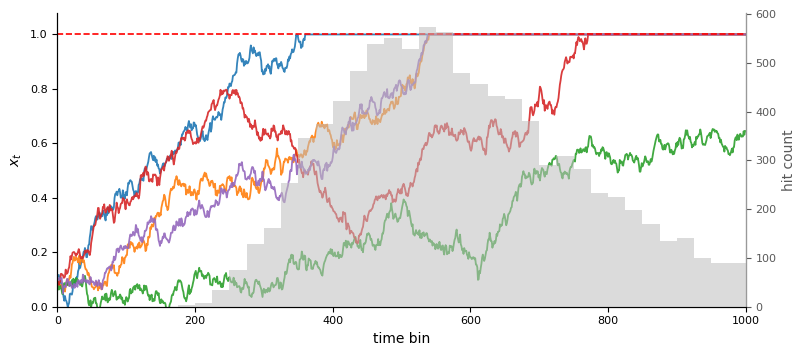

In [361]:
for beta, sigma in [(2.5,0.2), (1.5, 0.4)]:
    ramp = RampModel(beta=beta, sigma=sigma, x0=0.1, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=10000, T=1000)
    
    plot_ramp_trajectories_with_hit_hist(xs, bins = 40, max_trials=5)


# Task 1.2

In [363]:
def bin_spike_counts(spikes, bin_size=50):
    n_trials, T = spikes.shape

    bins = np.arange(0, T + bin_size, bin_size)
    bin_centres = (bins[:-1] + bins[1:]) / 2

    counts_per_trial = []

    for trial in range(n_trials):
        trial_counts = []

        for i in range(len(bins) - 1):
            start = bins[i]
            end = min(bins[i + 1], T)

            count = spikes[trial, start:end].sum()
            trial_counts.append(count)

        counts_per_trial.append(trial_counts)

    counts_per_trial = np.array(counts_per_trial)

    return counts_per_trial, bin_centres

In [364]:
def compute_psth(spikes, bin_size=50):
    n_trials, T = spikes.shape

    counts_per_trial, bin_centres = bin_spike_counts(spikes, bin_size)

    bin_width_seconds = bin_size / T
    psth = counts_per_trial.mean(axis=0) / bin_width_seconds

    return bin_centres, psth


def plot_psth(bin_centres, psth, T=None):
    plt.figure(figsize=(8, 3.5))
    
    plt.plot(bin_centres, psth)

    if T is not None:
        plt.xlim(0, T)

    plt.xlabel("time bin")
    plt.ylabel("firing rate (Hz)")
    plt.title("PSTH")
    plt.show()


def plot_multiple_psths(bin_centres_list, psth_list, labels, T=None, title="PSTHs"):
    plt.figure(figsize=(8, 3))

    colours = ["blue", "green", "red", "purple", "orange"]

    for i in range(len(psth_list)):
        plt.plot(
            bin_centres_list[i],
            psth_list[i],
            label=labels[i],
            color=colours[i],
            linewidth=1
        )

    if T is not None:
        plt.xlim(0, T)

    plt.xlabel("time bin")
    plt.ylabel("firing rate (Hz)")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

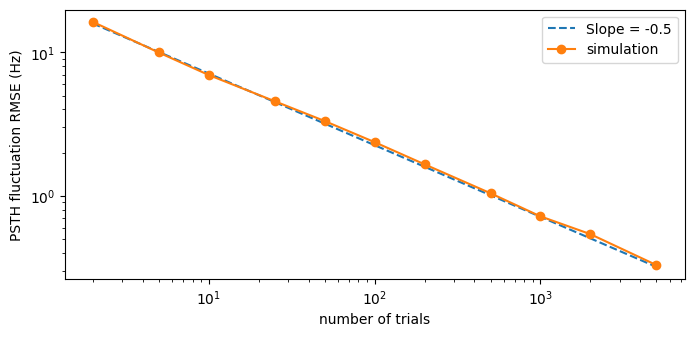

-0.4947304881740469


In [366]:
mean_rmses = []
Ns = [2, 5, 10, 25, 50, 100, 200, 500, 1000, 2000, 5000]
for N in Ns:
    
    psths = []
    for M in range(20):
        step = StepModel(m=500, r=10, x0=0.2, Rh=40)
        spikes , _, _ = step.simulate(Ntrials = N, T=1000)
        _, psth = compute_psth(spikes)
        psths.append(psth)

    psths = np.array(psths)

    mean_psth = psths.mean(axis=0)
    mses = np.mean((psths - mean_psth)**2, axis = 1)
    mean_rmse = np.sqrt(mses.mean())
    mean_rmses.append(mean_rmse)

slope, intercept = np.polyfit(
    np.log(Ns),
    np.log(mean_rmses),
    1
)

plt.figure(figsize=(8, 3.5))

fit_line = np.exp(intercept) * np.array(Ns) ** -0.5
plt.plot(Ns, fit_line, "--", label = f"Slope = -0.5")

plt.plot(Ns, mean_rmses, "o-", label="simulation")
plt.xlabel("number of trials")
plt.ylabel("PSTH fluctuation RMSE (Hz)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

print(slope)





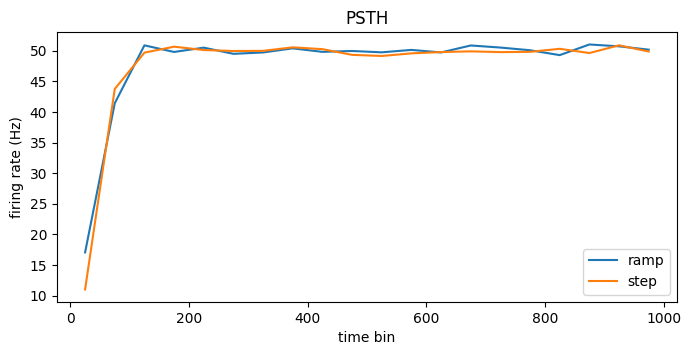

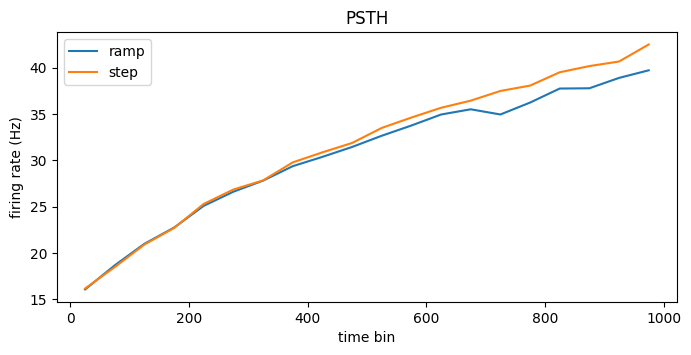

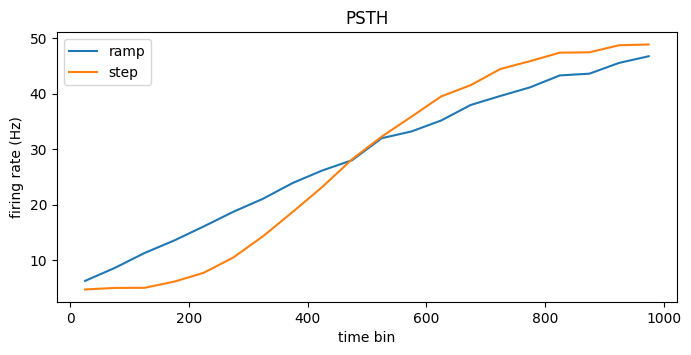

In [ ]:
T = 1000
Ntrials = 5000
bin_size = 50

def compare(beta, sigma, x0, Rh, m, r):
    ramp = RampModel(beta, sigma, x0, Rh)
    spikes_ramp, _, _ = ramp.simulate(Ntrials=Ntrials, T=T)
    bin_centres_ramp, psth_ramp = compute_psth(spikes_ramp, bin_size=bin_size)

    step = StepModel(m, r, x0, Rh)
    spikes_step, _, _ = step.simulate(Ntrials=Ntrials, T=T)
    bin_centres_step, psth_step = compute_psth(spikes_step, bin_size=bin_size)

    plt.figure(figsize=(8, 3.5))

    plt.plot(bin_centres_ramp, psth_ramp, label = "ramp")
    plt.plot(bin_centres_step, psth_step, label = "step")
    plt.xlabel("time bin")
    plt.ylabel("firing rate (Hz)")
    plt.title("PSTH")
    plt.legend()
    plt.show()
    

compare(beta=10, sigma=0.3, x0=0.1, Rh=50, m=50, r=10)

compare(beta=0.8, sigma=1, x0=0.3, Rh=50, m=700, r=1)

compare(beta=1, sigma=0.3, x0=0.1, Rh=50, m=500, r=6) #where different

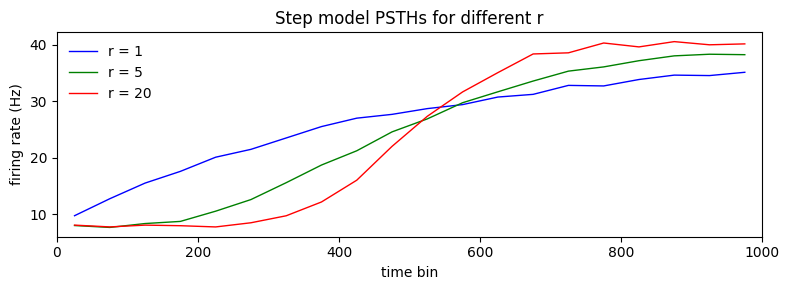

In [368]:
bin_centres_list = []
psth_list = []
labels = []

for r in [1, 5, 20]:
    step = StepModel(m=500, r=r, x0=0.2, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=5000, T=1000)

    bin_centres, psth = compute_psth(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    psth_list.append(psth)
    labels.append(f"r = {r}")

plot_multiple_psths(
    bin_centres_list,
    psth_list,
    labels,
    T=1000,
    title="Step model PSTHs for different r"
)

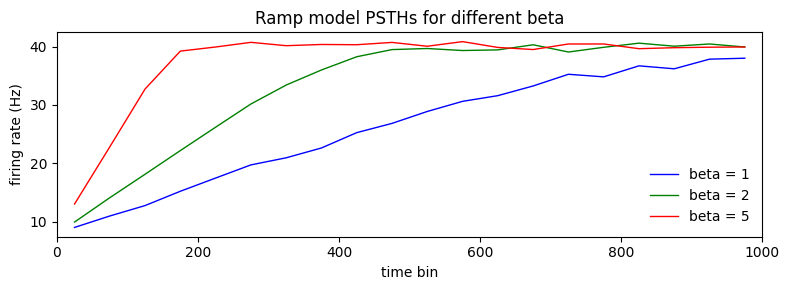

In [369]:
# Ramp model: varying beta

bin_centres_list = []
psth_list = []
labels = []

for beta in [1, 2, 5]:
    ramp = RampModel(beta=beta, sigma=0.3, x0=0.2, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=5000, T=1000)

    bin_centres, psth = compute_psth(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    psth_list.append(psth)
    labels.append(f"beta = {beta}")

plot_multiple_psths(
    bin_centres_list,
    psth_list,
    labels,
    T=1000,
    title="Ramp model PSTHs for different beta"
)

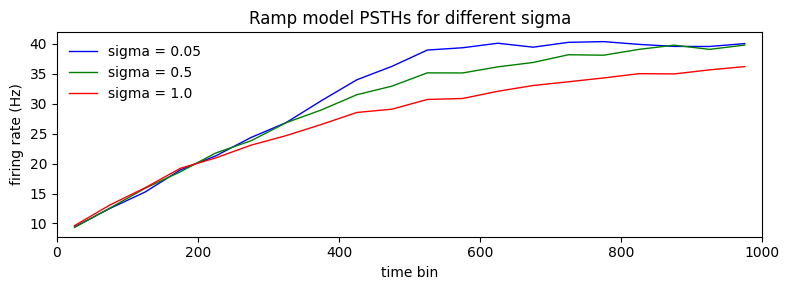

In [370]:
# Ramp model: varying sigma

bin_centres_list = []
psth_list = []
labels = []

for sigma in [0.05, 0.5, 1.0]:
    ramp = RampModel(beta=1.5, sigma=sigma, x0=0.2, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=5000, T=1000)

    bin_centres, psth = compute_psth(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    psth_list.append(psth)
    labels.append(f"sigma = {sigma}")

plot_multiple_psths(
    bin_centres_list,
    psth_list,
    labels,
    T=1000,
    title="Ramp model PSTHs for different sigma"
)

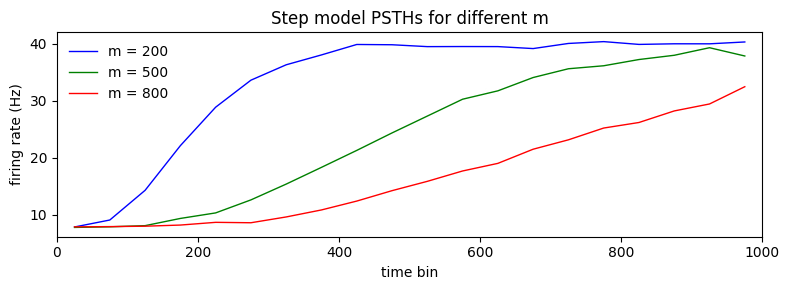

In [371]:
# Step model: varying m

bin_centres_list = []
psth_list = []
labels = []

for m in [200, 500, 800]:
    step = StepModel(m=m, r=5, x0=0.2, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=5000, T=1000)

    bin_centres, psth = compute_psth(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    psth_list.append(psth)
    labels.append(f"m = {m}")

plot_multiple_psths(
    bin_centres_list,
    psth_list,
    labels,
    T=1000,
    title="Step model PSTHs for different m"
)

# Task 1.3

In [372]:
def compute_fano(spikes, bin_size=50):
    counts_per_trial, bin_centres = bin_spike_counts(spikes, bin_size)

    mean_counts = counts_per_trial.mean(axis=0)
    variance_counts = counts_per_trial.var(axis=0)

    fano = variance_counts / (mean_counts)

    return fano, bin_centres


def plot_fano(fano, bin_centres):
    plt.plot(bin_centres, fano)

    if T is not None:
        plt.xlim(0, T)

    plt.xlabel("time bin")
    plt.ylabel("Fano Factor")
    plt.title("Fano Factor")
    plt.show()


def plot_multiple_fanos(bin_centres_list, fano_list, labels, T=None, title="Fano factors"):
    plt.figure(figsize=(8, 4))

    colours = ["blue", "green", "red", "purple", "orange"]

    for i in range(len(fano_list)):
        plt.plot(
            bin_centres_list[i],
            fano_list[i],
            label=labels[i],
            color=colours[i],
            linewidth=1
        )

    plt.axhline(
        1,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Poisson baseline"
    )

    if T is not None:
        plt.xlim(0, T)


    plt.xlabel("time bin")
    plt.ylabel("Fano factor")
    plt.title(title)

    legend = plt.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9
    )

    legend.set_zorder(100)

    plt.tight_layout()
    plt.show()


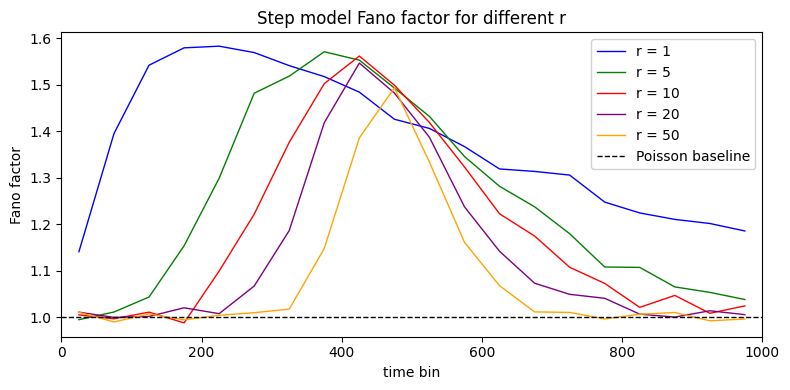

In [373]:
bin_centres_list = []
fano_list = []
labels = []

for r in [1, 5, 10, 20, 50]:
    step = StepModel(m=500, r=r, x0=0.2, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=20000, T=1000)

    fano, bin_centres = compute_fano(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    fano_list.append(fano)
    labels.append(f"r = {r}")

plot_multiple_fanos(
    bin_centres_list,
    fano_list,
    labels,
    T=1000,
    title="Step model Fano factor for different r"
)


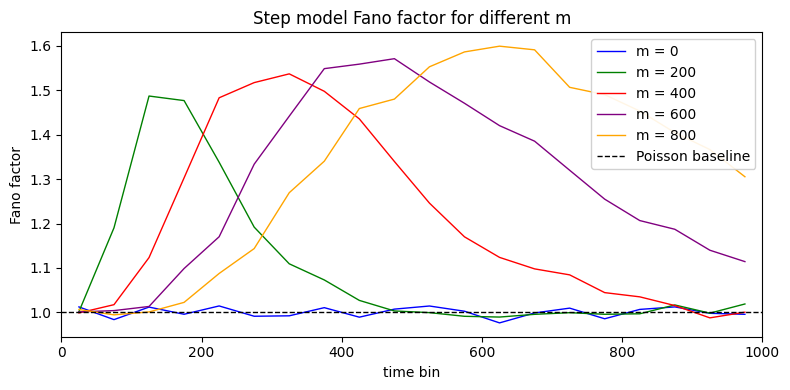

In [374]:
bin_centres_list = []
fano_list = []
labels = []

for m in [0, 200, 400, 600, 800]:
    step = StepModel(m=m, r=5, x0=0.2, Rh=40)
    spikes, jumps, rates = step.simulate(Ntrials=20000, T=1000)

    fano, bin_centres = compute_fano(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    fano_list.append(fano)
    labels.append(f"m = {m}")

plot_multiple_fanos(
    bin_centres_list,
    fano_list,
    labels,
    T=1000,
    title="Step model Fano factor for different m"
)

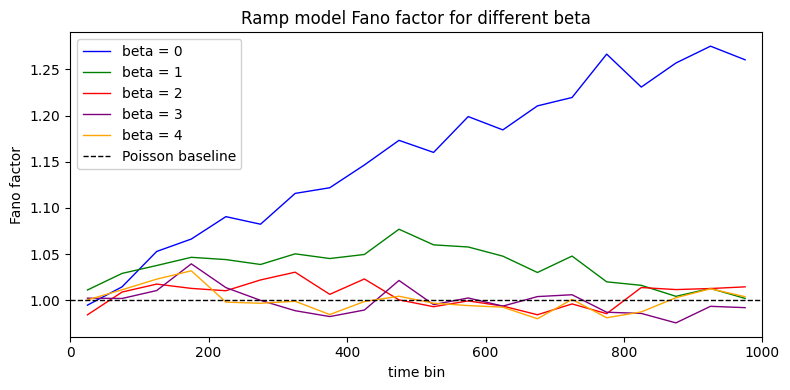

In [375]:
bin_centres_list = []
fano_list = []
labels = []

for beta in [0, 1, 2, 3, 4]:
    ramp = RampModel(beta=beta, sigma=0.2, x0=0.2, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=20000, T=1000)

    fano, bin_centres = compute_fano(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    fano_list.append(fano)
    labels.append(f"beta = {beta}")

plot_multiple_fanos(
    bin_centres_list,
    fano_list,
    labels,
    T=1000,
    title="Ramp model Fano factor for different beta"
)

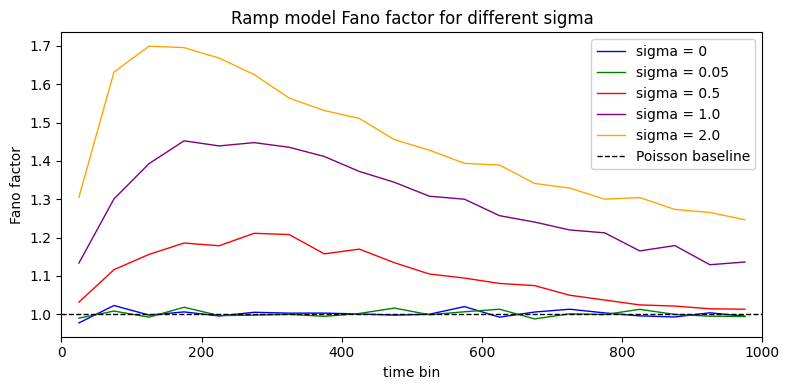

In [376]:
bin_centres_list = []
fano_list = []
labels = []

for sigma in [0, 0.05, 0.5, 1.0, 2.0]:
    ramp = RampModel(beta=1.5, sigma=sigma, x0=0.2, Rh=40)
    spikes, xs, rates = ramp.simulate(Ntrials=20000, T=1000)

    fano, bin_centres = compute_fano(spikes, bin_size=50)

    bin_centres_list.append(bin_centres)
    fano_list.append(fano)
    labels.append(f"sigma = {sigma}")

plot_multiple_fanos(
    bin_centres_list,
    fano_list,
    labels,
    T=1000,
    title="Ramp model Fano factor for different sigma"
)

In [377]:
def plot_rates_with_fano(spikes, rates, bin_size=50, max_trials=10, title="Title"):
    """
    Plots example firing-rate trajectories in the background and overlays
    the Fano factor on a second y-axis.

    spikes: shape (Ntrials, T)
    rates:  shape (Ntrials, T)
    """
    n_trials = min(rates.shape[0], max_trials)
    T = spikes.shape[1]

    fano, bin_centres = compute_fano(spikes, bin_size=bin_size)

    fig, ax_rate = plt.subplots(figsize=(8, 4))

    # Background firing-rate trajectories
    for trial in range(n_trials):
        ax_rate.plot(
            rates[trial],
            alpha=0.22,
            linewidth=1
        )

    ax_rate.set_xlim(0, T)
    ax_rate.set_xlabel("time bin")
    ax_rate.set_ylabel("firing rate (Hz)", color="gray")
    ax_rate.tick_params(axis="y", colors="gray")

    # Fano factor on second axis
    ax_fano = ax_rate.twinx()
    ax_fano.plot(
        bin_centres,
        fano,
        color="black",
        linewidth=2.2,
        label="Fano factor"
    )

    ax_fano.axhline(
        1,
        color="red",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label="Poisson baseline"
    )


    ax_fano.set_ylabel("Fano factor")
    ax_fano.legend(frameon=False, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()

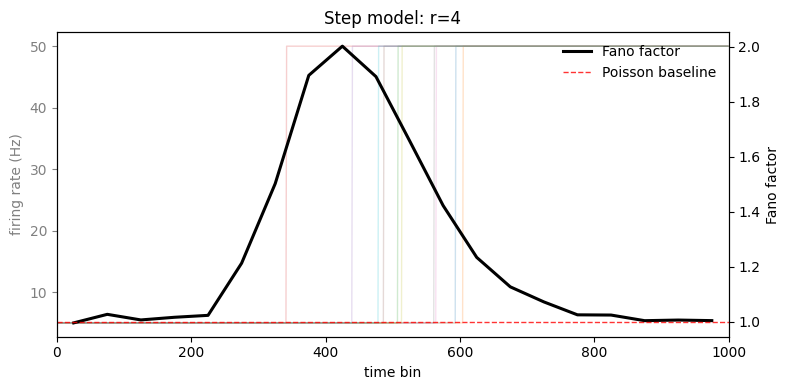

In [411]:
step = StepModel(m=500, r=20, x0=0.1, Rh=50)
spikes, jumps, rates = step.simulate(Ntrials=20000, T=1000)

plot_rates_with_fano(
    spikes,
    rates,
    bin_size=50,
    max_trials=10,
    title="Step model: m=500, r=20"
)




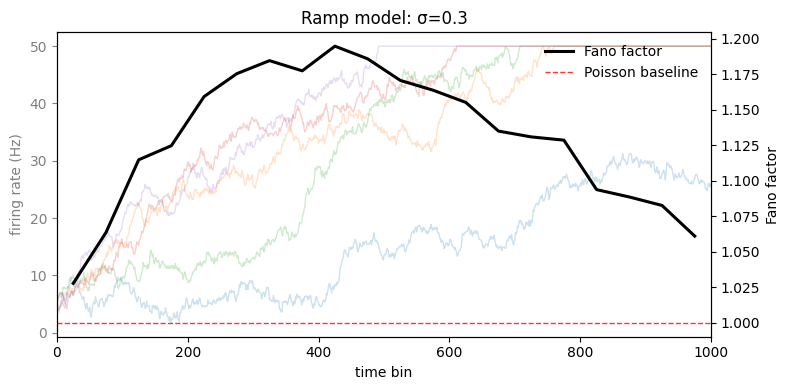

In [408]:
ramp = RampModel(beta=1, sigma=0.3, x0=0.1, Rh=50)
spikes, xs, rates = ramp.simulate(Ntrials=20000, T=1000)

plot_rates_with_fano(
    spikes,
    rates,
    bin_size=50,
    max_trials=5,
    title="Ramp model: σ=0.3"
)


# Task 1.4

Note the below function extract_features, includes code for all the trialled features but doesn't use it all.

In [381]:
#Tried training on various features - not all
feature_names = [
    "time_of_max_mean_slope",
    "max_mean_slope",
    "fano_peak",
    "variance_peak_width",
]

def extract_features(feature_names, spikes, bin_size=50):
    """
    Takes in the spike data from the 400 trials of one model and calculates 'features'
    Returns those features as a vector
    """

    n_trials, T = spikes.shape

    counts_per_trial, bin_centres = bin_spike_counts(spikes, bin_size)
    time = bin_centres / T

    # First moment:
    mean_counts = counts_per_trial.mean(axis=0)

    mean_rise = mean_counts[-1] - mean_counts[0]

    mean_slope = np.gradient(mean_counts, time)
    max_mean_slope = mean_slope.max()
    time_of_max_mean_slope = time[np.argmax(mean_slope)]

    # Second moment: Variance
    variance_counts = counts_per_trial.var(axis=0)

    peak_variance = variance_counts.max()
    time_of_peak_variance = time[np.argmax(variance_counts)]

    half_peak_level = peak_variance/2
    variance_peak_width = np.sum(variance_counts > half_peak_level) * bin_size / T


    # Fano features:
    fano = variance_counts / (mean_counts + 1e-12)

    fano_peak = fano.max()
    fano_min = fano.min()
    fano_range = fano_peak - fano_min
    time_of_peak_fano = time[np.argmax(fano)]

    half_fano_peak = 1 + (fano_peak - 1) / 2
    fano_peak_width = np.sum(fano > half_fano_peak) * bin_size / T


    #Third moment: skewness in each time bin

    std_counts = counts_per_trial.std(axis=0)
    centered_counts = counts_per_trial - mean_counts
    skewness = (centered_counts**3).mean(axis=0)/(std_counts**3+1e-12)
    skewness_peak = skewness.max()

    features_dict = {
        "max_mean_slope": max_mean_slope,
        "time_of_max_mean_slope": time_of_max_mean_slope,
        "variance_peak_width": variance_peak_width,
        "fano_peak": fano_peak,
    }

    feature_vector = np.array([features_dict[name] for name in feature_names])
    return feature_vector

In [ ]:
def simulate_random_ramp_dataset(Ntrials=400, T=1000, Rh=50):
    """
    Uniformly samples the parameters for the ramp model and runs 400 trials, returning the spike data and parameters
    """
    beta = np.random.uniform(0, 4)
    log_sigma = np.random.uniform(np.log(0.04), np.log(4))
    sigma = np.exp(log_sigma)
    x0 = np.random.uniform(0, 0.5)

    ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)
    spikes, xs, rates = ramp.simulate(Ntrials=Ntrials, T=T)

    params = {
        "beta": beta,
        "sigma": sigma,
        "x0": x0,
    }

    return spikes, params

    
def simulate_random_step_dataset(Ntrials=400, T=1000, Rh=50):
    """
    Uniformly samples the parameters for the step model and runs 400 trials, returning the spike data and parameters
    """
    m = np.random.uniform(T / 4, 3 * T / 4)
    r = np.random.uniform(0.5, 6)
    x0 = np.random.uniform(0, 0.5)

    step = StepModel(m=m, r=r, x0=x0, Rh=Rh)
    spikes, jumps, rates = step.simulate(Ntrials=Ntrials, T=T)

    params = {
        "m": m,
        "r": r,
        "x0": x0,
    }

    return spikes, params



def make_feature_dataset(feature_names, n_datasets_per_model=50, Ntrials=400, T=1000, Rh=50, bin_size=50):
    """
    Creates feature vectors for a no. different datasets for each model - each dataset with parameters uniformly sampled.
    Returns arrays x and y, and a list 'params_list'.
    x contains the features vectors for each dataset for each model.
    y contains whether the dataset was formed from a step or ramp model.
    params_list contains the samples parameters for each model.
    """
    x = []
    y = []
    params_list = []

    for i in range(n_datasets_per_model):
        spikes, params = simulate_random_ramp_dataset(Ntrials=Ntrials, T=T, Rh=Rh)
        feature_vector = extract_features(feature_names, spikes, bin_size=bin_size)

        x.append(feature_vector)
        y.append("ramp")
        params_list.append(params)

        spikes, params = simulate_random_step_dataset(Ntrials=Ntrials, T=T, Rh=Rh)
        feature_vector = extract_features(feature_names, spikes, bin_size=bin_size)

        x.append(feature_vector)
        y.append("step")
        params_list.append(params)

    x = np.array(x)
    y = np.array(y)

    return x, y, params_list


In [383]:
def plot_feature_histograms(x, y, feature_names):
    """
    Plots a histogram for each feature
    Each model was uniformly sampled, 400 trials run, then features calculated for each model and histogrammed here
    """
    n_features = x.shape[1]

    plt.figure(figsize=(14, 2 * n_features))

    for i, name in enumerate(feature_names):
        plt.subplot(n_features, 1, i + 1)

        plt.hist(
            x[y == "ramp", i],
            bins=20,
            alpha=0.6,
            label="ramp",
            density=True
        )

        plt.hist(
            x[y == "step", i],
            bins=20,
            alpha=0.6,
            label="step",
            density=True
        )

        plt.xlabel(name)
        plt.ylabel("density")
        plt.legend()

    plt.tight_layout()
    plt.show()



In [384]:
def standardise_features(x_train, x_test=None):
    """
    Takes in a feature dataset and normalises the features by mean and standard deviation 
    """
    feature_means = x_train.mean(axis=0)
    feature_stds = x_train.std(axis=0)

    x_train_standardised = (x_train - feature_means) / (feature_stds)

    if x_test is None:
        return x_train_standardised, feature_means, feature_stds

    x_test_standardised = (x_test - feature_means) / (feature_stds)

    return x_train_standardised, x_test_standardised, feature_means, feature_stds



def train_simple_linear_classifier(x_train, y_train):
    """
    Looks at a feature across all the different simulated models, and calculates the mean of the standardised feature for ramp and step

    The difference in the means between the two models is used as a weight
    So weight is a vector with length being number of features

    The midpoint between the feature means for each model type is calculated
    Midpoint is also a vector with length being number of features

    """
    
    x_train_standardised, feature_means, feature_stds = standardise_features(x_train)

    ramp_mean = x_train_standardised[y_train == "ramp"].mean(axis=0)
    step_mean = x_train_standardised[y_train == "step"].mean(axis=0)

    weights = step_mean - ramp_mean

    midpoint = (ramp_mean + step_mean) / 2

    classifier = {
        "feature_means": feature_means,
        "feature_stds": feature_stds,
        "ramp_mean": ramp_mean,
        "step_mean": step_mean,
        "weights": weights,
        "midpoint": midpoint,
    }

    return classifier


def classify_datasets(classifier, x):
    """
    Takes in the trained classifier and feature vectors from test (or train) datasets
    Standardises the test dataset using the classifier feature means and standard deviations
    
    Calculates a score for each sampled model dataset by taking it's standardised features, calculating the distance from the midpoint
    between the two models, and multiplying that by the weight

    i.e. when standardised features are further separated between step and ramp, and the test data is further from the midpoint,
    this will add a bigger score

    Returns the predictions and scores on the test data

    """
    feature_means = classifier["feature_means"]
    feature_stds = classifier["feature_stds"]
    weights = classifier["weights"]
    midpoint = classifier["midpoint"]

    x_standardised = (x - feature_means) / (feature_stds)

    scores = (x_standardised - midpoint) @ weights

    predictions = np.where(scores > 0, "step", "ramp")

    return predictions, scores

0.7675


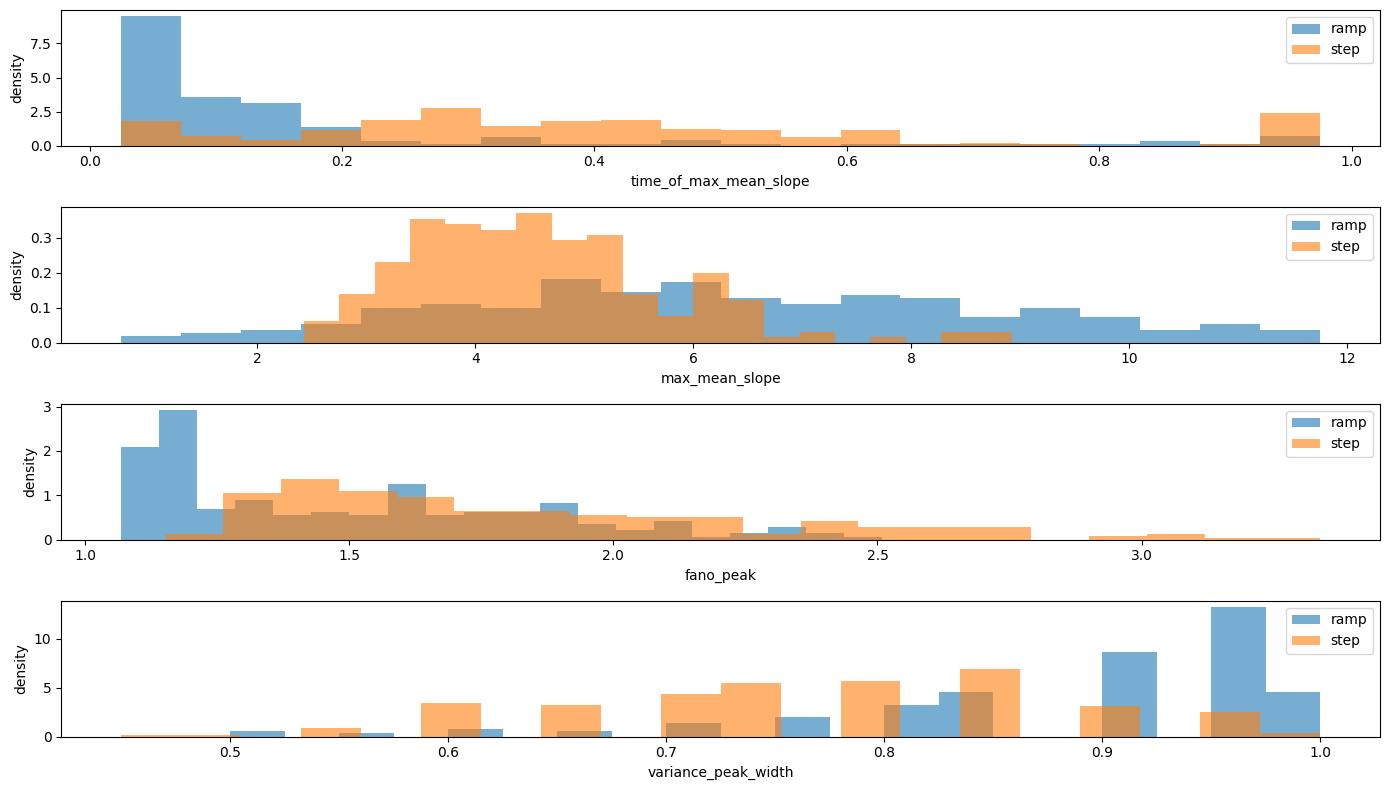

In [391]:
x_train, y_train, train_params = make_feature_dataset(feature_names, n_datasets_per_model=200)

classifier = train_simple_linear_classifier(x_train, y_train)

train_predictions, _ = classify_datasets(classifier, x_train)
train_accuracy = np.mean(train_predictions == y_train)
print(train_accuracy)

plot_feature_histograms(x_train, y_train, feature_names)




In [ ]:
x_test, y_test, test_params = make_feature_dataset(feature_names, n_datasets_per_model=100)

test_predictions, test_scores = classify_datasets(classifier, x_test)

overall_accuracy = np.mean(test_predictions == y_test)
ramp_accuracy = np.mean(test_predictions[y_test == "ramp"] == "ramp")
step_accuracy = np.mean(test_predictions[y_test == "step"] == "step")

print(f"Overall accuracy: {overall_accuracy}")
print(f"Ramp accuracy: {ramp_accuracy}")
print(f"Step accuracy: {step_accuracy}")

Overall accuracy: 0.805
Ramp accuracy: 0.82
Step accuracy: 0.79


In [395]:
def plot_classifier_scores(scores, y):
    plt.figure(figsize=(8, 3))

    plt.hist(
        scores[y == "ramp"],
        bins=20,
        alpha=0.6,
        label="ramp",
        density=True
    )

    plt.hist(
        scores[y == "step"],
        bins=20,
        alpha=0.6,
        label="step",
        density=True
    )

    plt.axvline(0, color="black", linestyle="--", label="decision boundary")

    plt.xlabel("classifier score")
    plt.ylabel("density")
    plt.legend()
    plt.show()


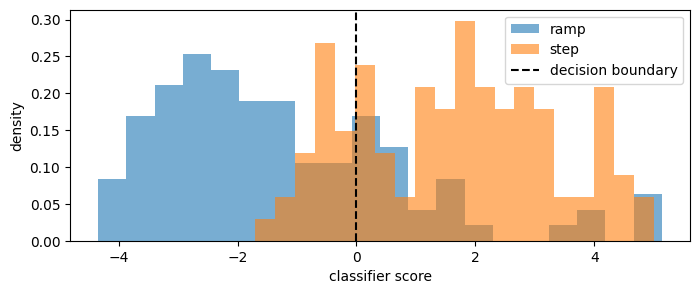

In [ ]:
test_predictions, test_scores = classify_datasets(classifier, x_test)
plot_classifier_scores(test_scores, y_test)